<a href="https://colab.research.google.com/github/sowmiyavetrivel28-git/-PMFBY-District-Crop-Insurance-Analysis-Using-Python_2018-2022-/blob/main/pythonProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage 1**


# 🌾 Project Title:
## **PMFBY District-Level Crop Insurance Performance Analysis Using  Python(2018–2022)**

# Dataset Information

- **Source:** India Data Portal / Government of India – PMFBY Data
- **Location:** India (State and District Level)
- **Year/Timeline:** 2018–2022
- **Domain:** Agriculture / Crop Insurance
- **Dataset:** Pradhan Mantri Fasal Bima Yojana (PMFBY)
- **Granularity:** District-Level, Seasonal Data
- **Seasons Covered:** Kharif and Rabi

## Problem Definition

Pradhan Mantri Fasal Bima Yojana (PMFBY) is a crop insurance scheme aimed at providing financial protection to farmers against crop-related risks. This project analyzes district-level PMFBY data from 2018 to 2022 to evaluate farmer participation, seasonal patterns, crop insurance coverage, premium and financial contributions, and demographic participation.

The analysis aims to identify variations in PMFBY performance across states and districts and derive meaningful, data-driven insights that can help understand participation, insurance coverage, and financial contribution patterns under the scheme.

# Objectives

## 1. Participation & Seasonal Analysis

- Analyze PMFBY participation across states and districts from 2018–2022.
- Compare PMFBY participation between Kharif and Rabi seasons.

## 2. Farmer Participation Analysis

- Analyze the participation pattern of Loanee and Non-Loanee farmers.
- Examine gender, social-category, and farmer-type participation patterns.

## 3. Insurance & Financial Analysis

- Evaluate crop insurance coverage across districts using insured area, insurance units, and sum insured.
- Analyze gross premium and the financial contributions of farmers, State Governments, and the Government of India.

## 4. District Performance Assessment

- Identify high- and low-performing districts based on PMFBY participation, insurance coverage, and financial indicators.

In [ ]:
# Importing Required Libraries

# Data manipulation and analysis
import pandas as pd

# Numerical calculations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Advanced statistical visualization
import seaborn as sns

In [ ]:
#  Loading Data from GITHUB

url ="https://raw.githubusercontent.com/sowmiyavetrivel28-git/-PMFBY-District-Crop-Insurance-Analysis-2018-2022-/main/agri_db.csv"

df = pd.read_csv(url)

df

,id,year,season,scheme,state_name,state_code,district_name,district_code,farmer_count,loanee,...,transgender,sc,st,obc,gen,marginal,small,other,iu_count,gross_premium
0,0,2018,Kharif,PMFBY,Andhra Pradesh,28,Anantapur,502.0,11455,11494.0,...,0.00,6.66,0.44,60.19,32.71,6.32,84.97,8.71,85,1024.79
1,1,2018,Kharif,PMFBY,Andhra Pradesh,28,Chittoor,503.0,22511,23368.0,...,0.06,6.41,0.81,39.90,52.88,16.82,75.32,7.86,614,894.25
2,2,2018,Kharif,PMFBY,Andhra Pradesh,28,East Godavari,505.0,152813,162278.0,...,0.06,4.81,1.34,37.67,56.18,12.82,81.93,5.25,1198,7451.91
3,3,2018,Kharif,PMFBY,Andhra Pradesh,28,Guntur,506.0,18045,18446.0,...,0.08,5.92,0.68,47.91,45.49,23.66,69.20,7.14,402,512.77
4,4,2018,Kharif,PMFBY,Andhra Pradesh,28,Krishna,510.0,77733,83378.0,...,0.04,5.21,0.50,34.74,59.55,31.88,60.80,7.32,836,3686.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6156,6156,2022,Rabi,WBCIS,Uttarakhand,5,Pithoragarh,53.0,61,20.0,...,0.00,25.70,3.17,9.86,61.27,15.49,84.51,0.00,9,3.03
6157,6157,2022,Rabi,WBCIS,Uttarakhand,5,Rudraprayag,54.0,568,22.0,...,0.00,13.44,0.31,0.31,85.94,4.89,94.66,0.45,4,2.69
6158,6158,2022,Rabi,WBCIS,Uttarakhand,5,Tehri Garhwal,55.0,10220,3153.0,...,0.02,4.24,0.55,59.55,35.66,16.01,82.71,1.28,14,3037.27
6159,6159,2022,Rabi,WBCIS,Uttarakhand,5,Udham Singh Nagar,NaN,141,15.0,...,0.00,9.41,18.82,20.59,51.18,4.12,95.29,0.59,7,4.65


# **INITIAL DATA INSPECTION**

In [ ]:
# take a copy of the dataset:

df_safe=df.copy()

In [ ]:
#View the structure of the dataset

df.shape

(6161, 28)

In [ ]:
# view first few rows

df.head(5)

,id,year,season,scheme,state_name,state_code,district_name,district_code,farmer_count,loanee,...,transgender,sc,st,obc,gen,marginal,small,other,iu_count,gross_premium
0,0,2018,Kharif,PMFBY,Andhra Pradesh,28,Anantapur,502.0,11455,11494.0,...,0.00,6.66,0.44,60.19,32.71,6.32,84.97,8.71,85,1024.79
1,1,2018,Kharif,PMFBY,Andhra Pradesh,28,Chittoor,503.0,22511,23368.0,...,0.06,6.41,0.81,39.90,52.88,16.82,75.32,7.86,614,894.25
2,2,2018,Kharif,PMFBY,Andhra Pradesh,28,East Godavari,505.0,152813,162278.0,...,0.06,4.81,1.34,37.67,56.18,12.82,81.93,5.25,1198,7451.91
3,3,2018,Kharif,PMFBY,Andhra Pradesh,28,Guntur,506.0,18045,18446.0,...,0.08,5.92,0.68,47.91,45.49,23.66,69.20,7.14,402,512.77
4,4,2018,Kharif,PMFBY,Andhra Pradesh,28,Krishna,510.0,77733,83378.0,...,0.04,5.21,0.50,34.74,59.55,31.88,60.80,7.32,836,3686.23


In [ ]:
# Dataset Columns

df.columns

Index(['id', 'year', 'season', 'scheme', 'state_name', 'state_code',
       'district_name', 'district_code', 'farmer_count', 'loanee',
       'non_loanee', 'area_insured', 'sum_insured', 'farmer_share',
       'goi_share', 'state_share', 'male', 'female', 'transgender', 'sc', 'st',
       'obc', 'gen', 'marginal', 'small', 'other', 'iu_count',
       'gross_premium'],
      dtype='object')

In [ ]:
# Dataset Information and Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6161 entries, 0 to 6160
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             6161 non-null   int64  
 1   year           6161 non-null   int64  
 2   season         6161 non-null   object 
 3   scheme         6161 non-null   object 
 4   state_name     6161 non-null   object 
 5   state_code     6161 non-null   int64  
 6   district_name  6161 non-null   object 
 7   district_code  5422 non-null   float64
 8   farmer_count   6161 non-null   int64  
 9   loanee         6160 non-null   float64
 10  non_loanee     6161 non-null   int64  
 11  area_insured   6161 non-null   float64
 12  sum_insured    6161 non-null   float64
 13  farmer_share   6161 non-null   float64
 14  goi_share      6161 non-null   float64
 15  state_share    6161 non-null   float64
 16  male           6091 non-null   float64
 17  female         6091 non-null   float64
 18  transgen

In [ ]:
#Statistical Summary of Numerical Variables

df.describe()

,id,year,state_code,district_code,farmer_count,loanee,non_loanee,area_insured,sum_insured,farmer_share,...,transgender,sc,st,obc,gen,marginal,small,other,iu_count,gross_premium
count,6161.000000,6161.000000,6161.000000,5422.000000,6.161000e+03,6.160000e+03,6.161000e+03,6161.000000,6161.000000,6161.000000,...,6091.000000,6091.000000,6091.000000,6091.000000,6091.000000,6091.000000,6091.000000,6091.000000,6161.000000,6161.000000
mean,3080.000000,2019.811394,19.093491,353.080044,2.480393e+04,4.164701e+04,1.832689e+04,41.400735,15993.387038,321.786437,...,0.066231,5.777285,10.114815,38.529521,45.578380,21.478861,60.304365,18.216774,228.533355,2255.688911
std,1778.671836,1.426377,9.796734,204.740547,4.736395e+04,1.238617e+05,9.170390e+04,124.914868,32988.035495,705.065074,...,0.539522,7.197323,19.721359,25.163139,29.148505,18.039795,23.586045,20.998843,297.982625,6187.390408
min,0.000000,2018.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,-0.010000,0.000000,0.000000,0.000000,-0.010000,0.000000,0.000000,-0.010000,0.000000,0.000000
25%,1540.000000,2019.000000,9.000000,144.000000,3.120000e+02,1.020000e+02,2.500000e+01,0.150000,86.430000,1.590000,...,0.000000,1.290000,0.150000,15.975000,19.950000,9.210000,46.925000,3.470000,12.000000,8.050000
50%,3080.000000,2020.000000,22.000000,387.000000,5.628000e+03,3.045500e+03,2.950000e+02,4.300000,2554.020000,39.290000,...,0.020000,4.100000,1.190000,38.770000,42.120000,17.030000,60.500000,10.870000,84.000000,202.150000
75%,4620.000000,2021.000000,27.000000,527.000000,2.971500e+04,2.824800e+04,3.165000e+03,30.940000,15099.570000,284.720000,...,0.070000,7.785000,8.650000,58.825000,71.025000,28.495000,78.930000,25.260000,354.000000,1342.230000
max,6160.000000,2022.000000,36.000000,755.000000,1.061490e+06,2.180401e+06,2.062026e+06,3777.400000,535572.470000,8600.320000,...,30.940000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2492.000000,80103.400000


In [ ]:
# Missing Value Analysis

df.isnull().sum()

,0
id,0
year,0
season,0
scheme,0
state_name,0
state_code,0
district_name,0
district_code,739
farmer_count,0
loanee,1


In [ ]:
# Data Types of Variables

df.dtypes

,0
id,int64
year,int64
season,object
scheme,object
state_name,object
state_code,int64
district_name,object
district_code,float64
farmer_count,int64
loanee,float64


In [ ]:
#checking the duplicate values:

df.duplicated().sum()

np.int64(0)

# **Stage - 2**

Data Cleaning,Data Transformation ,Feature Engineering and Final EDA

Handle duplicates

Handle missing values (impute or drop)

column name rename or dropping unwanted columns

Treat outliers if required(optional)

Convert data types if needed

Data Transformation or Data Wrangling

Final EDA

# **DATA CLEANING**



# **Data Cleaning – ID Column**

In [ ]:
#1.Check Missing Values in ID

df["id"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check ID Data Type

df["id"].dtype

dtype('int64')

In [ ]:
# 3.Renaming id Column

df.rename(columns={"id": "Id"}, inplace=True)

# **Data Cleaning – Year Column**



In [ ]:
# 1. Check Missing Values in Year

df["year"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Year Data Type

df["year"].dtype

dtype('int64')

In [ ]:
# 3. Check Unique Year Values

df["year"].unique()

array([2018, 2019, 2020, 2021, 2022])

In [ ]:
# 4. Check Year Value Counts

df["year"].value_counts().sort_index()

,count
year,
2018,1498
2019,1385
2020,1137
2021,1063
2022,1078


In [ ]:
# 5. Renaming year column

df.rename(columns={"year": "Year"}, inplace=True)

# **Data Cleaning – Season Column**



In [ ]:
# 1. Check Missing Values in Season

df["season"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Unique Season Values

df["season"].unique()

array(['Kharif', 'Rabi'], dtype=object)

In [ ]:
# 3. Check Season Value Counts

df["season"].value_counts()

,count
season,
Rabi,3103
Kharif,3058


In [ ]:
# 4. Check Season Data Type

df["season"].dtype

dtype('O')

In [ ]:
# 5. Renaming season column

df.rename(columns={"season": "Season"}, inplace=True)

# **Data Cleaning – Scheme Column**



In [ ]:
# 1. Check Missing Values in Scheme

df["scheme"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Unique Scheme Values

df["scheme"].unique()

array(['PMFBY', 'WBCIS'], dtype=object)

In [ ]:
# 3. Check Scheme Value Counts

df["scheme"].value_counts()

,count
scheme,
PMFBY,4416
WBCIS,1745


In [ ]:
# 4. Check Scheme Data Type

df["scheme"].dtype

dtype('O')

In [ ]:
# 5. Renaming Scheme column

df.rename(columns={"scheme": "Scheme"}, inplace=True)

# **Data Cleaning – State Name Column**


In [ ]:
# 1. Check Missing Values in State Name

df["state_name"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Unique State Names

df["state_name"].unique()

array(['Andhra Pradesh', 'Assam', 'Chhattisgarh', 'Madhya Pradesh',
       'Karnataka', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu And Kashmir', 'Jharkhand', 'Kerala', 'Maharashtra',
       'Odisha', 'Puducherry', 'Rajasthan', 'Tamil Nadu', 'Sikkim',
       'Telangana', 'West Bengal', 'Uttar Pradesh', 'Uttarakhand',
       'Tripura', 'Meghalaya', 'Manipur', 'Andaman And Nicobar Islands'],
      dtype=object)

In [ ]:
# 3. Check State Name Values Counts

df["state_name"].value_counts()

,count
state_name,
Uttar Pradesh,923
Madhya Pradesh,708
Maharashtra,594
Chhattisgarh,536
Rajasthan,498
Karnataka,330
Tamil Nadu,305
Odisha,297
Assam,277


In [ ]:
# 5. Check State Name Data Type

df["state_name"].dtype

dtype('O')

In [ ]:
# Renaming State Name Column

df.rename(columns={"state_name": "State_Name"}, inplace=True)

# **Data Cleaning – State Code Column**



In [ ]:
# 1. Check Missing Values in State Code

df["state_code"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check State Code Data Type

df["state_code"].dtype

dtype('int64')

In [ ]:
# 3.Renaming State Code Column

df.rename(columns={"state_code": "State_Code"}, inplace=True)

# **Data Cleaning – District Name Column**



In [ ]:
# 1. Check Missing Values in District Name

df["district_name"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Leading and Trailing Spaces

df[df["district_name"].str.strip() != df["district_name"]][
    ["district_name"]
].drop_duplicates()

,district_name


In [ ]:
# 3. Check Capitalization / Title Case

df[df["district_name"] != df["district_name"].str.title()][
    ["district_name"]
].drop_duplicates()

,district_name


In [ ]:
# 4. Standardize District Name Format

df["district_name"] = df["district_name"].str.strip()

In [ ]:
# 5. Check District Name Values Counts

df["district_name"].value_counts()

,count
district_name,
Bilaspur,39
Balrampur,35
Raigarh,31
Pratapgarh,27
Hamirpur,21
...,...
Ri Bhoi,1
South Garo Hills,1
Boudh,1


In [ ]:
# Renaming District Name Column

df.rename(columns={"district_name": "District_Name"}, inplace=True)

# **Removing unnecessary column**

In [ ]:
# Removing Unnecessary District Code Column

df.drop(columns=["district_code"], inplace=True)

# **Data Cleaning – Farmer Count Column**



In [ ]:
# 1. Check Missing Values

df["farmer_count"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Data Type

df["farmer_count"].dtype

dtype('int64')

In [ ]:
# 3. Renaming Farmer Count Column

df.rename(columns={"farmer_count": "Farmer_Count"}, inplace=True)

# **Data Cleaning – Loanee Column**

In [ ]:
# 1. Check Missing Values

df["loanee"].isnull().sum()

np.int64(1)

In [ ]:
# 2. Check Data Type

df["loanee"].dtype

dtype('float64')

In [ ]:
# 3. Renaming Loanee Column

df.rename(columns={"loanee": "Loanee"}, inplace=True)

In [ ]:
# 4. Identify Missing Loanee Records

df.loc[df["Loanee"].isnull(), [
    "State_Name", "District_Name", "Year", "Season",
    "Farmer_Count", "non_loanee"
]]

,State_Name,District_Name,Year,Season,Farmer_Count,non_loanee
1726,Karnataka,Gadag,2019,Kharif,5,5


In [ ]:
# 5. Impute Missing Loanee Value Using District-Season Median

loanee_median = df[
    (df["District_Name"] == "Gadag") &
    (df["Season"] == "Kharif")
]["Loanee"].median()

df["Loanee"] = df["Loanee"].fillna(loanee_median)

In [ ]:
# 6.change the datatype of the loanee column to integer

df["Loanee"] = df["Loanee"].astype(int)

# **Data Cleaning – Non-Loanee Column**

In [ ]:
# 1. Check Missing Values

df["non_loanee"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Data Type

df["non_loanee"].dtype

dtype('int64')

In [ ]:
# 3. Rename Non-Loanee Column

df.rename(columns={"non_loanee": "Non_Loanee"}, inplace=True)

# **Data Cleaning – Area Insured Column**

In [ ]:
# 1. Check Missing Values

df["area_insured"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Data Type

df["area_insured"].dtype

dtype('float64')

In [ ]:
# 3. Check Negative Values

(df["area_insured"] < 0).sum()

np.int64(0)

In [ ]:
# 4. Rename area_insured Column

df.rename(columns={"area_insured": "Area_Insured"}, inplace=True)

# **Data Cleaning – Sum Insured Column**

In [ ]:
# 1. Check Missing Values

df["sum_insured"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Data Type

df["sum_insured"].dtype

dtype('float64')

In [ ]:
# 3. Check Negative Values

(df["sum_insured"] < 0).sum()

np.int64(0)

In [ ]:
# 4. Rename sum_insured Column

df.rename(columns={"sum_insured": "Sum_Insured"}, inplace=True)

# **Data Cleaning – Farmer Share Column**

In [ ]:
# 1. Check Missing Values

df["farmer_share"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Rename farmer_share Column

df.rename(columns={"farmer_share": "Farmer_Share"}, inplace=True)

In [ ]:
# 3. Check Data Type

df["Farmer_Share"].dtype

dtype('float64')

In [ ]:
# 4. Check Negative Values

(df["Farmer_Share"] < 0).sum()

np.int64(0)

# **Data Cleaning – GOI Share Column**

In [ ]:
# 1. Check Missing Values

df["goi_share"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Data Type

df["goi_share"].dtype

dtype('float64')

In [ ]:
# 3. Check Negative Values

(df["goi_share"] < 0).sum()

np.int64(0)

In [ ]:
# 4. Rename GOI Share Column

df.rename(columns={"goi_share": "GOI_Share"}, inplace=True)

# **Data Cleaning – State Share Column**

In [ ]:
# 1. Check Missing Values

df["state_share"].isnull().sum()

np.int64(0)

In [ ]:
# 2. Check Data Type

df["state_share"].dtype

dtype('float64')

In [ ]:
# 3. Check Negative Values

(df["state_share"] < 0).sum()

np.int64(0)

In [ ]:
# 4. Rename State Share Column

df.rename(columns={"state_share": "State_Share"}, inplace=True)

# **Data Cleaning – Male Column**

In [ ]:
df["male"] = df_safe["male"]

In [ ]:
# 1. Check Missing Values

df["male"].isnull().sum()

np.int64(70)

In [ ]:
#2. statistial analysis of Male column

df["male"].describe()

,male
count,6091.000000
mean,85.910186
std,10.709759
min,0.000000
25%,81.920000
50%,88.730000
75%,92.160000
max,100.000000


In [ ]:
# 3. Hierarchical Imputation for Missing Male Values

df["male"] = df["male"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["male"].transform("median")
)

df["male"] = df["male"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["male"].transform("median")
)

df["male"] = df["male"].fillna(
    df.groupby(["State_Name", "Season"])["male"].transform("median")
)

df["male"] = df["male"].fillna(
    df.groupby("Season")["male"].transform("median")
)

In [ ]:
# 4. Check Data Type

df["male"].dtype

dtype('float64')

In [ ]:
# 5. Rename Male Column

df.rename(columns={"male": "Male"}, inplace=True)

# **Data Cleaning – Female Column**

In [ ]:
# 1. Check Missing Values

df["female"].isnull().sum()

np.int64(70)

In [ ]:
# 2. statistical analysis of the female column

df["female"].describe()

,female
count,6161.000000
mean,14.057010
std,10.603189
min,0.000000
25%,7.800000
50%,11.270000
75%,18.140000
max,100.000000


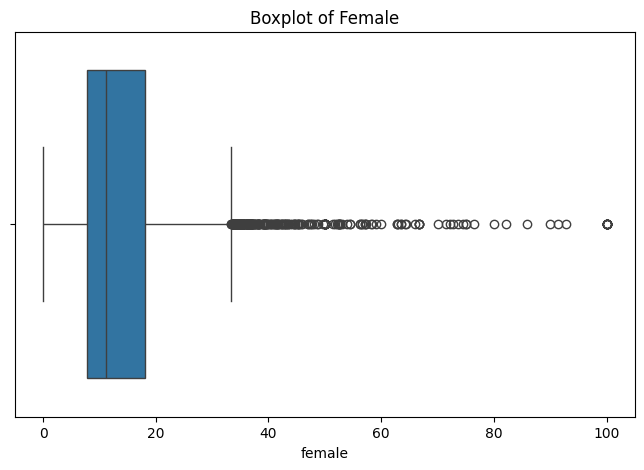

In [ ]:
# 3.Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["female"])
plt.title("Boxplot of Female")
plt.show()

In [ ]:
# 4. Hierarchical Imputation for Missing Female Values

df["female"] = df["female"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["female"].transform("median")
)

df["female"] = df["female"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["female"].transform("median")
)

df["female"] = df["female"].fillna(
    df.groupby(["State_Name", "Season"])["female"].transform("median")
)

df["female"] = df["female"].fillna(
    df.groupby("Season")["female"].transform("median")
)

In [ ]:
# 5. Rename Female Column

df.rename(columns={"female": "Female"}, inplace=True)



# **Data Cleaning – Transgender Column**

In [ ]:
# check missing values

df["transgender"].isnull().sum()

np.int64(70)

In [ ]:
df["transgender"].describe()

,transgender
count,6091.000000
mean,0.066231
std,0.539522
min,-0.010000
25%,0.000000
50%,0.020000
75%,0.070000
max,30.940000


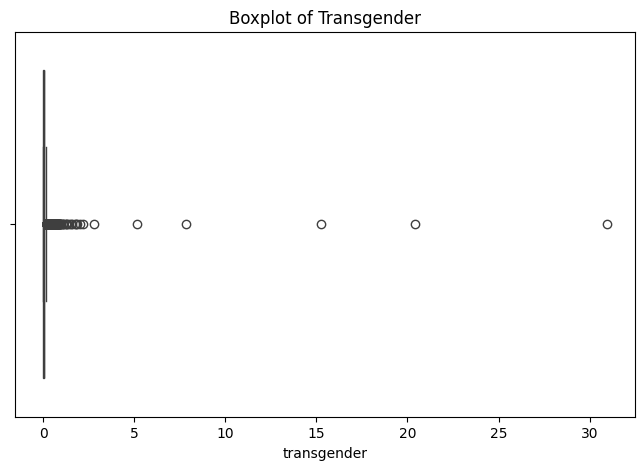

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["transgender"])
plt.title("Boxplot of Transgender")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing Transgender Values

df["transgender"] = df["transgender"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["transgender"].transform("median")
)

df["transgender"] = df["transgender"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["transgender"].transform("median")
)



In [ ]:
#Date type check

df["transgender"].dtype

dtype('float64')

In [ ]:
# Rename Transgender Column

df.rename(columns={"transgender": "Transgender"}, inplace=True)

# **Data Cleaning – SC Column**

In [ ]:
# Check Missing Values

df["sc"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of sc column

df["sc"].describe()

,sc
count,6091.000000
mean,5.777285
std,7.197323
min,0.000000
25%,1.290000
50%,4.100000
75%,7.785000
max,100.000000


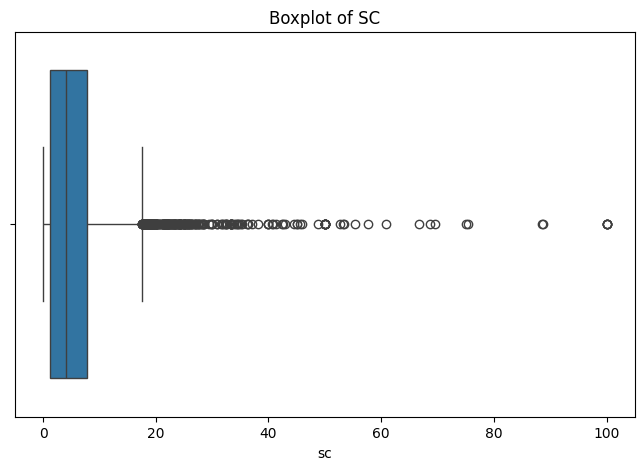

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["sc"])
plt.title("Boxplot of SC")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing SC Values

df["sc"] = df["sc"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["sc"].transform("median")
)

df["sc"] = df["sc"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["sc"].transform("median")
)


In [ ]:
# Rename sc Column

df.rename(columns={"sc": "SC"}, inplace=True)

In [ ]:
# Data type check

df["Sc"].dtype

dtype('float64')

# **Data Cleaning – ST Column**

In [ ]:
#Check Missing Values

df["st"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of st column

df["st"].describe()

,st
count,6091.000000
mean,10.114815
std,19.721359
min,0.000000
25%,0.150000
50%,1.190000
75%,8.650000
max,100.000000


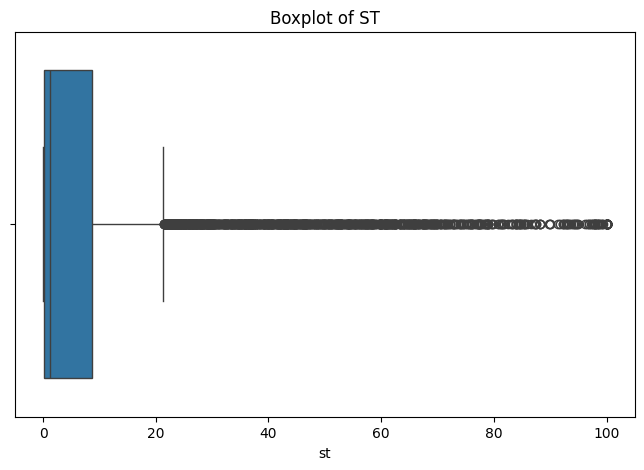

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["st"])
plt.title("Boxplot of ST")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing ST Values

df["st"] = df["st"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["st"].transform("median")
)

df["st"] = df["st"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["st"].transform("median")
)

df["st"] = df["st"].fillna(
    df.groupby(["State_Name", "Season"])["st"].transform("median")
)

In [ ]:
# Rename ST Column

df.rename(columns={"st": "ST"}, inplace=True)

In [ ]:
# data type check

df["ST"].dtype

dtype('float64')

# **Data Cleaning – OBC Column**

In [ ]:
# Check Missing Values

df["obc"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of obc column

df["obc"].describe()

,obc
count,6091.000000
mean,38.529521
std,25.163139
min,0.000000
25%,15.975000
50%,38.770000
75%,58.825000
max,100.000000


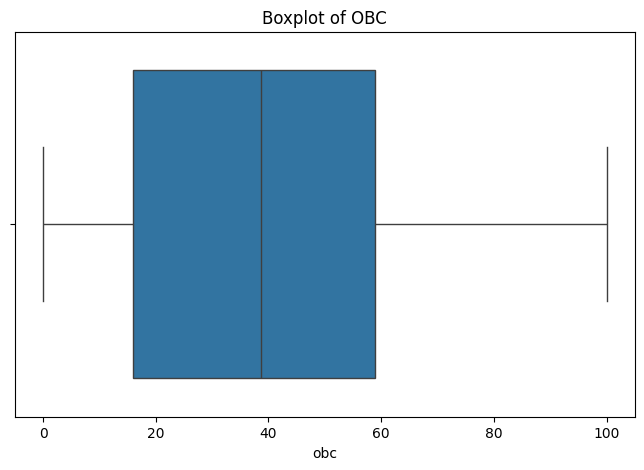

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["obc"])
plt.title("Boxplot of OBC")
plt.show()

In [ ]:
# Hierarchical Median Imputation

df["obc"] = df["obc"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["obc"].transform("median")
)

df["obc"] = df["obc"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["obc"].transform("median")
)

In [ ]:
# Rename OBC Column

df.rename(columns={"obc": "OBC"}, inplace=True)

In [ ]:
# Data type check

df["OBC"].dtype

dtype('float64')

# **Data Cleaning – General (GEN) Column**

In [ ]:
# Check Missing Values

df["gen"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of gen column

df["gen"].describe()

,gen
count,6091.000000
mean,45.578380
std,29.148505
min,-0.010000
25%,19.950000
50%,42.120000
75%,71.025000
max,100.000000


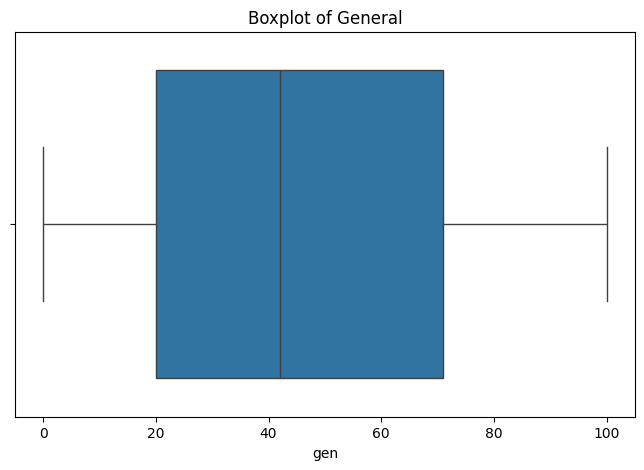

In [ ]:
#  Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["gen"])
plt.title("Boxplot of General")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing General Values

df["gen"] = df["gen"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["gen"].transform("median")
)

df["gen"] = df["gen"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["gen"].transform("median")
)

In [ ]:
# Check Data Type

df["gen"].dtype

dtype('float64')

In [ ]:
# Rename General Column

df.rename(columns={"gen": "General"}, inplace=True)

# **Data Cleaning – Marginal Column**

In [ ]:
# Check Missing Values

df["marginal"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of marginal column

df["Marginal"].describe()

,Marginal
count,6161.000000
mean,21.437500
std,17.988937
min,0.000000
25%,9.290000
50%,16.990000
75%,28.440000
max,100.000000


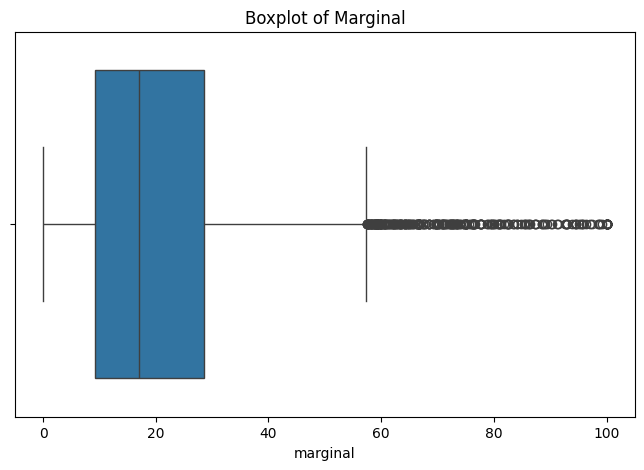

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["marginal"])
plt.title("Boxplot of Marginal")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing Marginal Values

df["marginal"] = df["marginal"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["marginal"].transform("median")
)

df["marginal"] = df["marginal"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["marginal"].transform("median")
)

In [ ]:
# Check Data Type

df["marginal"].dtype

dtype('float64')

In [ ]:
# Rename Marginal Column

df.rename(columns={"marginal": "Marginal"}, inplace=True)

# **Data Cleaning – Small Column**

In [ ]:
# Check Missing Values

df["small"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of small column

df["small"].describe()

,small
count,6091.000000
mean,60.304365
std,23.586045
min,0.000000
25%,46.925000
50%,60.500000
75%,78.930000
max,100.000000


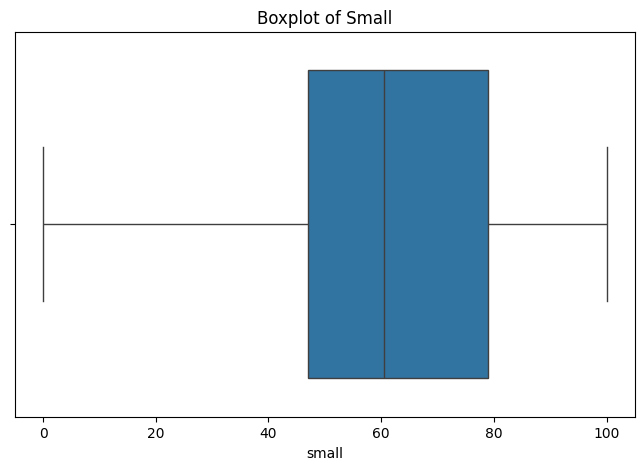

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["small"])
plt.title("Boxplot of Small")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing Small Values

df["small"] = df["small"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["small"].transform("median")
)

df["small"] = df["small"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["small"].transform("median")
)

In [ ]:
# Check Data Type

df["small"].dtype

dtype('float64')

In [ ]:
# Rename Small Column

df.rename(columns={"small": "Small"}, inplace=True)

# **Data Cleaning – Other Column**

In [ ]:
# Check Missing Values

df["other"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of other column

df["other"].describe()

,other
count,6091.000000
mean,18.216774
std,20.998843
min,-0.010000
25%,3.470000
50%,10.870000
75%,25.260000
max,100.000000


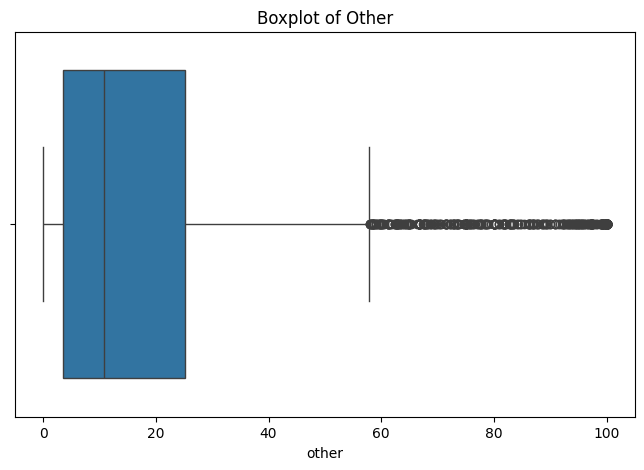

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["other"])
plt.title("Boxplot of Other")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing Other Values

df["other"] = df["other"].fillna(
    df.groupby(["District_Name", "Year", "Season"])["other"].transform("median")
)

df["other"] = df["other"].fillna(
    df.groupby(["State_Name", "Year", "Season"])["other"].transform("median")
)

In [ ]:
# Rename Other Column

df.rename(columns={"other": "Other"}, inplace=True)

# **Data Cleaning – IU Count Column**

In [ ]:
# Check Missing Values

df["iu_count"].isnull().sum()

np.int64(0)

In [ ]:
# Check Data Type

df["iu_count"].dtype

dtype('int64')

In [ ]:
# Check Negative Values

(df["iu_count"] < 0).sum()

np.int64(0)

In [ ]:
# Rename IU Count Column

df.rename(columns={"iu_count": "Insurance_Units"}, inplace=True)

# **Data Cleaning – Gross Premium Column**

In [ ]:
# Check Missing Values

df["gross_premium"].isnull().sum()

np.int64(0)

In [ ]:
# Check Data Type

df["gross_premium"].dtype

dtype('float64')

In [ ]:
# Check Negative Values

(df["gross_premium"] < 0).sum()

np.int64(0)

In [ ]:
# Rename Gross Premium Column

df.rename(columns={"gross_premium": "Gross_Premium"}, inplace=True)

# **🔧 Feature Engineering**

In [ ]:
# 1. Create Total Applications

df["Total_Applications"] = df["Loanee"] + df["Non_Loanee"]

In [ ]:
# 2. Create Total Government Contribution

df["Total_Government_Share"] = df["GOI_Share"] + df["State_Share"]

In [ ]:
# 3. Create Total Premium Contribution

df["Total_Premium_Contribution"] = (
    df["Farmer_Share"] +
    df["GOI_Share"] +
    df["State_Share"]
)

In [ ]:
# 4. Insurance_Per_Application

df["Insurance_Per_Application"] = (
    df["Sum_Insured"] / df["Total_Applications"]
)


# **FINAL EDA**

In [ ]:
# Check null values:

df.isnull().sum()

,0
id,0
Year,0
Season,0
Scheme,0
State_Name,0
State_Code,0
District_Name,0
Farmer_Count,0
Loanee,0
Non_Loanee,0


In [ ]:
df["Total_Applications"].isnull().sum()

np.int64(0)

In [ ]:
df["Sum_Insured"].isnull().sum()

np.int64(0)

In [ ]:
df[df["Total_Applications"] == 0][
    ["Total_Applications", "Sum_Insured", "Insurance_Per_Application"]
]

,Total_Applications,Sum_Insured,Insurance_Per_Application
97,0,0.0,NaN
112,0,0.0,NaN
220,0,0.0,NaN
337,0,0.0,NaN
942,0,0.0,NaN
...,...,...,...
3621,0,0.0,NaN
3622,0,0.0,NaN
3623,0,0.0,NaN
3624,0,0.0,NaN


In [ ]:
df["Insurance_Per_Application"] = df["Insurance_Per_Application"].fillna(0)

In [ ]:
df.isnull().sum()

,0
id,0
Year,0
Season,0
Scheme,0
State_Name,0
State_Code,0
District_Name,0
Farmer_Count,0
Loanee,0
Non_Loanee,0


In [ ]:
pd.set_option("display.max_columns", None)
df.head()

,id,Year,Season,Scheme,State_Name,State_Code,District_Name,Farmer_Count,Loanee,Non_Loanee,Area_Insured,Sum_Insured,Farmer_Share,GOI_Share,State_Share,Female,Transgender,Sc,ST,OBC,General,Marginal,Small,Other,Insurance_Units,Gross_Premium,Male,Total_Applications,Total_Government_Share,Total_Premium_Contribution,Insurance_Per_Application
0,0,2018,Kharif,PMFBY,Andhra Pradesh,28,Anantapur,11455,11494,587,17.44,9493.41,453.87,285.46,285.46,33.44,0.00,6.66,0.44,60.19,32.71,6.32,84.97,8.71,85,1024.79,66.56,12081,570.92,1024.79,0.785813
1,1,2018,Kharif,PMFBY,Andhra Pradesh,28,Chittoor,22511,23368,16,18.82,22410.65,792.39,50.93,50.93,29.42,0.06,6.41,0.81,39.90,52.88,16.82,75.32,7.86,614,894.25,70.52,23384,101.86,894.25,0.958375
2,2,2018,Kharif,PMFBY,Andhra Pradesh,28,East Godavari,152813,162278,3516,97.88,71316.82,1482.17,2984.87,2984.87,35.49,0.06,4.81,1.34,37.67,56.18,12.82,81.93,5.25,1198,7451.91,64.45,165794,5969.74,7451.91,0.430153
3,3,2018,Kharif,PMFBY,Andhra Pradesh,28,Guntur,18045,18446,2044,16.75,12411.11,255.87,128.45,128.45,34.43,0.08,5.92,0.68,47.91,45.49,23.66,69.20,7.14,402,512.77,65.49,20490,256.90,512.77,0.605715
4,4,2018,Kharif,PMFBY,Andhra Pradesh,28,Krishna,77733,83378,215,60.88,56967.44,1196.91,1244.66,1244.66,31.90,0.04,5.21,0.50,34.74,59.55,31.88,60.80,7.32,836,3686.23,68.06,83593,2489.32,3686.23,0.681486
